In [10]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, warnings

# Suppressing TensorFlow logging for cleaner terminal output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensuring reproducibility across computational runs
tf.random.set_seed(42)
np.random.seed(42)

# Loading the engineered dataset and the pre-selected informative sensors
df = pd.read_csv('../data/processed/FD001_with_rul.csv')
with open('../data/processed/useful_sensors.json') as f:
    useful_sensors = json.load(f)

print(f"Dataset loaded successfully. Shape: {df.shape}")
print(f"Active Sensors: {useful_sensors}")

Dataset loaded successfully. Shape: (20631, 92)
Active Sensors: ['s2', 's3', 's4', 's7', 's9', 's12', 's14', 's17']


In [2]:
# Defining the sliding window lookback period
WINDOW = 30
FEATURES = useful_sensors + ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Reconstructing the exact test split used in baseline models to ensure fair benchmarking
engines = df['unit_id'].unique()
np.random.seed(42)
test_engines = np.random.choice(engines, size=int(0.2 * len(engines)), replace=False)
train_mask = ~df['unit_id'].isin(test_engines)
test_mask  =  df['unit_id'].isin(test_engines)

# Applying MinMax scaling to bound features between [0, 1] for faster neural network convergence
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

def build_sequences(data, window=WINDOW):
    """
    Transforms time-series tabular data into 3D sequences (samples, time_steps, features)
    required for LSTM neural network input.
    """
    X_list, y_list = [], []
    for _, group in data.groupby('unit_id'):
        group = group.sort_values('cycle')
        feats = group[FEATURES].values
        rul   = group['RUL'].values
        for i in range(window, len(feats)):
            X_list.append(feats[i-window:i])
            y_list.append(rul[i])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Generating 3D sequential data for training and testing sets
X_train, y_train = build_sequences(df_scaled[train_mask])
X_test,  y_test  = build_sequences(df_scaled[test_mask])

print(f"Training Sequences: X={X_train.shape} | y={y_train.shape}")
print(f"Testing Sequences:  X={X_test.shape}  | y={y_test.shape}")
print(f"Expected LSTM Input Shape: (Batch Size, {WINDOW}, {len(FEATURES)})")

Training Sequences: X=(14161, 30, 11) | y=(14161,)
Testing Sequences:  X=(3470, 30, 11)  | y=(3470,)
Expected LSTM Input Shape: (Batch Size, 30, 11)


In [3]:
def build_lstm(input_shape):
    """
    Constructs a Deep LSTM architecture utilizing Batch Normalization and Dropout
    layers to prevent overfitting on sequential data.
    """
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    
    # Compiling the model with Huber loss for robustness against outliers
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='huber', 
        metrics=['mae']
    )
    return model

# Initializing the LSTM model and displaying its architectural summary
model = build_lstm((WINDOW, len(FEATURES)))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,969 (484.25 KB)

 Trainable params: 123,585 (482.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [4]:
# Defining callbacks to dynamically adjust learning rate and stop early if validation plateaus
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Executing deep learning training over the generated sequences
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

# Serializing the trained model for future deployment
model.save('../results/models/lstm_rul.keras')
print("Deep Learning LSTM model saved successfully.")

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 74.6550 - mae: 75.1529 - val_loss: 78.7630 - val_mae: 79.2610 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 65.2620 - mae: 65.7586 - val_loss: 60.7296 - val_mae: 61.2278 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 52.8534 - mae: 53.3485 - val_loss: 47.2781 - val_mae: 47.7761 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 39.3377 - mae: 39.8333 - val_loss: 39.5335 - val_mae: 40.0313 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 24.1900 - mae: 24.6849 - val_loss: 33.5210 - val_mae: 34.0190 - learning_rate: 0.0010
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 18.7741 - mae: 19.2672 - val_loss: 40.8541 - val_mae: 41.3528 - learning_rate: 0.0010
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 17.9925 - mae: 18.4855 - val_loss: 37.1266 - val_mae: 37.6243 -

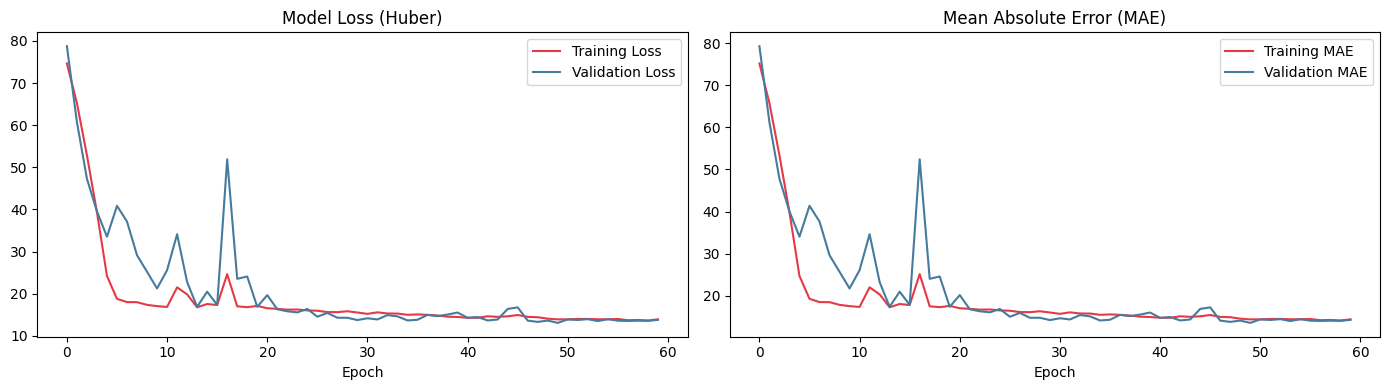

In [5]:
# Visualizing training stability and model convergence over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Training Loss', color='#e63946')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#457b9d')
axes[0].set_title('Model Loss (Huber)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE', color='#e63946')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#457b9d')
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lstm_training_curve.png', dpi=150)
plt.show()

In [6]:
def nasa_score(y_true, y_pred):
    """
    Computes NASA's asymmetric scoring metric.
    Penalizes late predictions (overestimating RUL) more heavily than early predictions.
    """
    diff = y_pred - y_true
    score = np.sum(np.where(diff < 0,
                            np.exp(-diff / 13) - 1,
                            np.exp(diff / 10) - 1))
    return score

# Generating final predictions on the unseen testing set
y_pred = model.predict(X_test, verbose=0).flatten()

# Calculating evaluation metrics
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
mae   = mean_absolute_error(y_test, y_pred)
score = nasa_score(y_test, y_pred)

print(f"LSTM Evaluation -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | NASA Score: {score:.1f}")

LSTM Evaluation -> RMSE: 14.47 | MAE: 10.24 | NASA Score: 17344.2


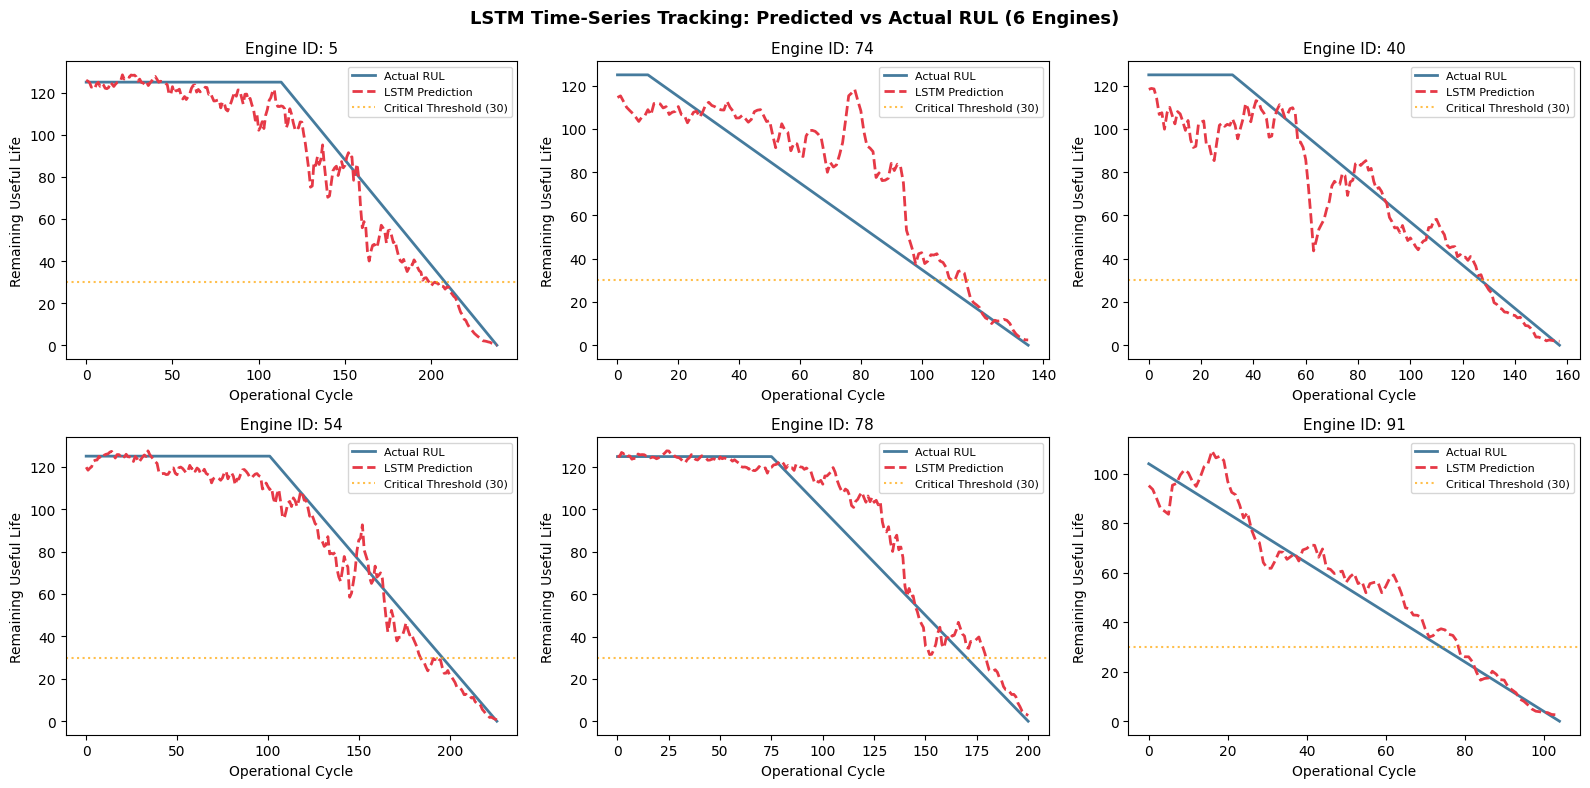

In [7]:
# Visualizing LSTM predictive tracking on a random sample of 6 test engines
sample_engines = np.random.choice(list(test_engines), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, eng in zip(axes.flatten(), sample_engines):
    group = df_scaled[df_scaled['unit_id'] == eng].sort_values('cycle')
    feats = group[FEATURES].values
    rul_true = group['RUL'].values
    
    preds = []
    # Simulating real-time sequence prediction cycle by cycle
    for i in range(WINDOW, len(feats)):
        seq = feats[i-WINDOW:i][np.newaxis, :, :]
        preds.append(model.predict(seq, verbose=0)[0][0])
    
    ax.plot(rul_true[WINDOW:], label='Actual RUL', color='#457b9d', linewidth=2)
    ax.plot(preds,             label='LSTM Prediction', color='#e63946', linewidth=2, linestyle='--')
    ax.axhline(30, color='orange', linestyle=':', alpha=0.7, label='Critical Threshold (30)')
    
    ax.set_title(f'Engine ID: {eng}', fontsize=11)
    ax.set_xlabel('Operational Cycle'); ax.set_ylabel('Remaining Useful Life')
    ax.legend(fontsize=8)

plt.suptitle('LSTM Time-Series Tracking: Predicted vs Actual RUL (6 Engines)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/lstm_predictions.png', dpi=150)
plt.show()

In [8]:
# Loading previous baseline benchmark results to append the new LSTM model
benchmark = pd.read_csv('../results/benchmark_table.csv')

lstm_row = pd.DataFrame([{
    'Model': 'LSTM',
    'RMSE':  round(rmse, 2),
    'MAE':   round(mae, 2),
    'NASA_Score': round(score, 1)
}])

# Appending LSTM metrics and sorting the final leaderboard
benchmark = pd.concat([benchmark, lstm_row], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
benchmark.to_csv('../results/benchmark_table.csv', index=False)
print("\n--- Final Model Benchmark ---")
print(benchmark.to_string(index=False))


--- Final Model Benchmark ---
            Model  RMSE   MAE   NASA_Score
    Random Forest  1.50  0.74   327.500000
          XGBoost  1.72  0.99   427.200000
Linear Regression  9.46  7.55  5115.300000
 Ridge Regression 11.05  8.86  6567.200000
             LSTM 14.47 10.24 17344.199219


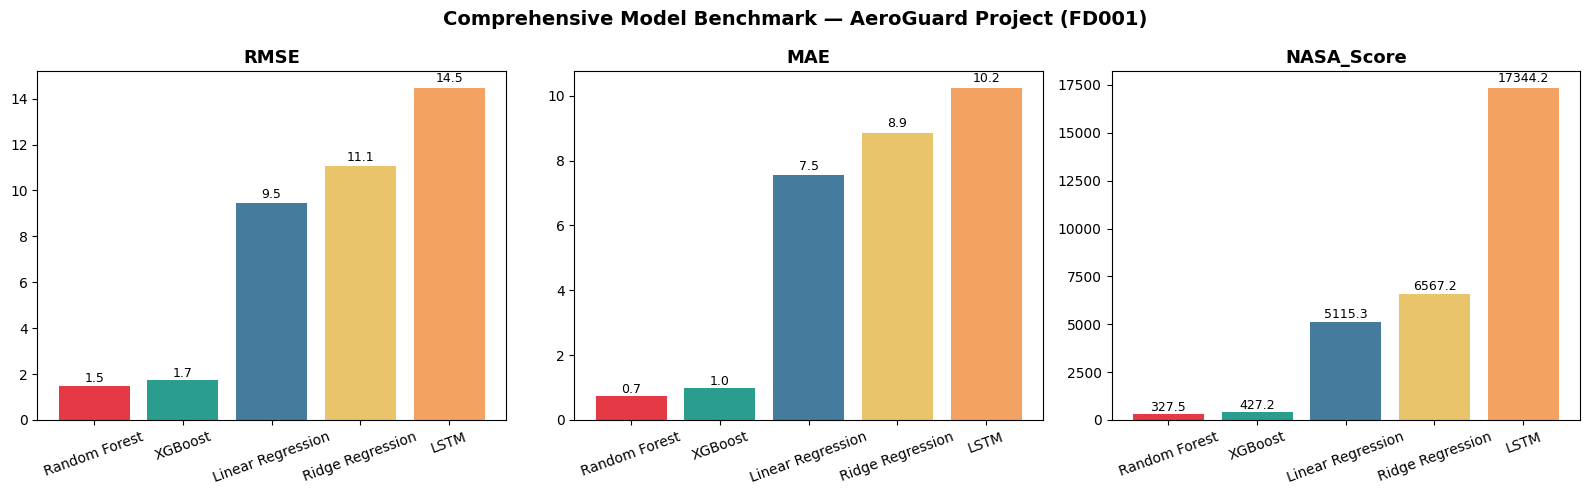

Top performing architecture based on RMSE: Random Forest


In [9]:
# Visualizing the comprehensive benchmark comparing Classical ML vs Deep Learning
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#e63946','#2a9d8f','#457b9d','#e9c46a','#f4a261']
bm = benchmark.sort_values('RMSE').reset_index(drop=True)

for ax, metric in zip(axes, ['RMSE', 'MAE', 'NASA_Score']):
    bars = ax.bar(bm['Model'], bm[metric], color=palette[:len(bm)])
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    
    # Annotating bar heights with metric values
    for bar, val in zip(bars, bm[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comprehensive Model Benchmark — AeroGuard Project (FD001)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/benchmark_final.png', dpi=150)
plt.show()

print(f"Top performing architecture based on RMSE: {bm.iloc[0]['Model']}")